# Задание №2: Построение нейронной сети для машинного перевода (Seq2Seq LSTM)

## Лабораторная работа по дисциплине "Глубокое обучение" ака "Глубинное обучение"

**Цель работы:** Построить модель Seq2Seq на базе LSTM для перевода с русского на английский язык.

В работе будет намеренно использованы синтетические данные, поскольку их словари меньше, значит меньше времени на обучение и модель слабее быстро подхватит закономерности. На практике попробовал обучить через данные `*.txt` файлов и вышло так, что модель не улавливала закономерности, это чинится если использовать механизмы внимания и делать не простые нейронки типа LSTM, а например Transformer, но пример учебный и в задании сказано, что можно использовать синтетические данные (можно и не использовать их, но тогда точность перевода просто ужаснейшая).

## 1. Теоретическое введение

### 1.1 Ключевые понятия NLP
- **Корпус (Corpus)** — структурированная коллекция текстов для обучения NLP моделей
- **Токенизация (Tokenization)** — разбиение текста на минимальные единицы (токены)
- **Эмбеддинги (Embeddings)** — векторные представления слов
- **Seq2Seq** — архитектура для преобразования последовательности в последовательность
- **LSTM** — Long Short-Term Memory, тип рекуррентной сети
- **Инференс (Inference)** — использование обученной модели для предсказаний
- **Специальные токены**: `<start>` — начало, `<end>` — конец предложения

## 2. Подготовка окружения и импорты

In [1]:
print('ok')

ok


In [2]:
# Импорт необходимых библиотек
import numpy as np
import tensorflow as tf
from keras.models import Model, load_model
from keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import pickle
import random
import os
from sklearn.model_selection import train_test_split

# Настройка случайныхseed для воспроизводимости
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Версия TensorFlow:", tf.__version__)
print("Импорты успешно загружены")

Версия TensorFlow: 2.20.0
Импорты успешно загружены


## 3. Генерация синтетических данных

При отсутствии реального параллельного корпуса генерируем синтетические данные.

In [3]:
def generate_synthetic_data(num_pairs=5000):
    """
    Генерация синтетических данных для машинного перевода.
    Русские фразы -> Английские фразы
    """
    rus_sentences = []
    eng_sentences = []
    
    # Словарь соответствий слов
    word_pairs = {
        'кот': 'cat', 'собака': 'dog', 'мышь': 'mouse', 'дом': 'house',
        'видит': 'sees', 'ловит': 'catches', 'бежит': 'runs',
        'большой': 'big', 'маленький': 'small', 'красный': 'red',
        'синий': 'blue', 'зеленый': 'green', 'желтый': 'yellow'
    }
    
    templates_rus = [
        "кот видит собаку",
        "собака бежит в дом",
        "маленький кот ловит мышь",
        "большой дом",
        "мышь бежит",
        "кот видит мышь",
        "собака ловит мышь",
        "маленький кот",
        "большой кот",
        "маленькая собака",
        "большая собака",
        "кот в доме",
        "собака видит кота",
        "мышь в доме",
        "красный дом",
        "синий дом",
        "зеленый дом",
        "желтый кот"
    ]
    
    for _ in range(num_pairs):
        rus = random.choice(templates_rus)
        # Перевод: замена слов по словарю
        eng = rus
        for ru, en in word_pairs.items():
            eng = eng.replace(ru, en)
        
        rus_sentences.append(rus)
        eng_sentences.append(eng)
    
    return rus_sentences, eng_sentences

# Генерация датасета
NUM_PAIRS = 5000
russian_sentences, english_sentences = generate_synthetic_data(NUM_PAIRS)

print(f"Сгенерировано {len(russian_sentences)} пар предложений")
print(f"Пример: русский: '{russian_sentences[0]}' -> английский: '{english_sentences[0]}'")

Сгенерировано 5000 пар предложений
Пример: русский: 'большой дом' -> английский: 'big house'


## 4. Загрузка и первичный анализ данных

In [4]:
# Попробуем загрузить файлы russian.txt и english.txt
# Если файлы отсутствуют, используем сгенерированные данные

try:
    with open('/russian.txt', encoding='utf-8') as f:
        raw_russian = [line.strip() for line in f if line.strip()]
    with open('/english.txt', encoding='utf-8') as f:
        raw_english = [line.strip() for line in f if line.strip()]
    
    # Уравниваем количество примеров
    num_samples = min(len(raw_russian), len(raw_english))
    raw_russian = raw_russian[:num_samples]
    raw_english = raw_english[:num_samples]
    
    print(f"Загружено из файлов: {num_samples} пар предложений")
    print(f"Пример: русский: {raw_russian[0]} -> английский: {raw_english[0]}")
    
except FileNotFoundError:
    print("Файлы корпуса не найдены, используем синтетические данные")
    raw_russian = russian_sentences
    raw_english = english_sentences
    num_samples = len(raw_russian)
    print(f"Используем синтетические данные: {num_samples} пар")

# Статистика корпуса
print(f"\n=== Статистика корпуса ===")
print(f"Количество пар предложений: {num_samples}")

# Анализ длин предложений
rus_lengths = [len(s.split()) for s in raw_russian]
eng_lengths = [len(s.split()) for s in raw_english]

print(f"Средняя длина русских предложений: {np.mean(rus_lengths):.2f} слов")
print(f"Средняя длина английских предложений: {np.mean(eng_lengths):.2f} слов")
print(f"Максимальная длина русских: {max(rus_lengths)}, английских: {max(eng_lengths)}")

Файлы корпуса не найдены, используем синтетические данные
Используем синтетические данные: 5000 пар

=== Статистика корпуса ===
Количество пар предложений: 5000
Средняя длина русских предложений: 2.54 слов
Средняя длина английских предложений: 2.54 слов
Максимальная длина русских: 4, английских: 4


## 5. Токенизация и подготовка последовательностей

In [5]:
# Добавляем маркеры начала и конца к английским предложениям
targets_marked = ['start_ ' + t + ' end_' for t in raw_english]

# Токенизация русского текста (вход)
input_tokenizer = Tokenizer(filters='', lower=True)
input_tokenizer.fit_on_texts(raw_russian)
input_seqs = input_tokenizer.texts_to_sequences(raw_russian)
encoder_input_data = pad_sequences(input_seqs, padding='post')
num_encoder_tokens = len(input_tokenizer.word_index) + 1

# Токенизация английского текста с маркерами (выход)
target_tokenizer = Tokenizer(filters='', lower=True)
target_tokenizer.fit_on_texts(targets_marked)
target_seqs = target_tokenizer.texts_to_sequences(targets_marked)

# Для декодера вход: без последнего слова; целевые данные: без первого слова
decoder_input_data = pad_sequences([s[:-1] for s in target_seqs], padding='post')
decoder_target_data = pad_sequences([s[1:] for s in target_seqs], padding='post')

# Преобразуем целевые данные в one-hot формат
decoder_target_one_hot = tf.keras.utils.to_categorical(
    decoder_target_data, 
    num_classes=len(target_tokenizer.word_index) + 1
)

num_decoder_tokens = len(target_tokenizer.word_index) + 1

print(f"Размер русского словаря: {num_encoder_tokens}")
print(f"Размер английского словаря: {num_decoder_tokens}")
print(f"Форма входных данных энкодера: {encoder_input_data.shape}")
print(f"Форма входных данных декодера: {decoder_input_data.shape}")
print(f"Форма целевых данных (one-hot): {decoder_target_one_hot.shape}")

Размер русского словаря: 20
Размер английского словаря: 22
Форма входных данных энкодера: (5000, 4)
Форма входных данных декодера: (5000, 5)
Форма целевых данных (one-hot): (5000, 5, 22)


## 6. Разделение на обучающую и валидационную выборки

In [6]:
# Разделим индексы, так как данные связаны
indices = np.arange(num_samples)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

encoder_train = encoder_input_data[train_idx]
encoder_val = encoder_input_data[val_idx]

decoder_train_in = decoder_input_data[train_idx]
decoder_val_in = decoder_input_data[val_idx]

decoder_train_out = decoder_target_one_hot[train_idx]
decoder_val_out = decoder_target_one_hot[val_idx]

print(f"Обучающих примеров: {len(train_idx)}")
print(f"Валидационных примеров: {len(val_idx)}")

Обучающих примеров: 4000
Валидационных примеров: 1000


## 7. Построение модели Seq2Seq

In [7]:
latent_dim = 512  # размер скрытого состояния

# Энкодер
encoder_inputs = Input(shape=(None,), name='encoder_input')
enc_emb = Embedding(num_encoder_tokens, latent_dim, name='encoder_embedding')(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Декодер
decoder_inputs = Input(shape=(None,), name='decoder_input')
dec_emb_layer = Embedding(num_decoder_tokens, latent_dim, name='decoder_embedding')
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

# Модель для обучения
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("=== Архитектура модели Seq2Seq ===")
model.summary()

=== Архитектура модели Seq2Seq ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 512) │     10,240 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 512) │     11,264 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 512),     │  2,099,200 │ encoder_embeddin… │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │  2,099,200 │ decoder_embeddin… │
│                     │ 512), (None,      │            │ encoder_lstm[0][… │
│                     │ 512), (None,      │            │ encoder_lstm[0][… │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 22)  │     11,286 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,231,190 (16.14 MB)

 Trainable params: 4,231,190 (16.14 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Обучение модели

In [8]:
%%time

# Колбеки для обучения
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Обучение модели
EPOCHS = 30
BATCH_SIZE = 64

history = model.fit(
    [encoder_train, decoder_train_in],
    decoder_train_out,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([encoder_val, decoder_val_in], decoder_val_out),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7418 - loss: 0.9294 - val_accuracy: 0.9774 - val_loss: 0.0433
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9987 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 9.0084e-04 - val_accuracy: 1.0000 - val_loss: 6.6408e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 5.2995e-04 - val_accuracy: 1.0000 - val_loss: 4.2677e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 3.5719e-04 - val_accuracy: 1.0000 - val_loss: 3.0096e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 1.0000 - loss: 2.5975e-04 - val_accuracy: 1.0000 - val_loss: 2.2525e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 1.9858e-04 - val_accuracy: 1.0000 - val_loss: 1.7565e-04
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 -

## 9. Визуализация процесса обучения

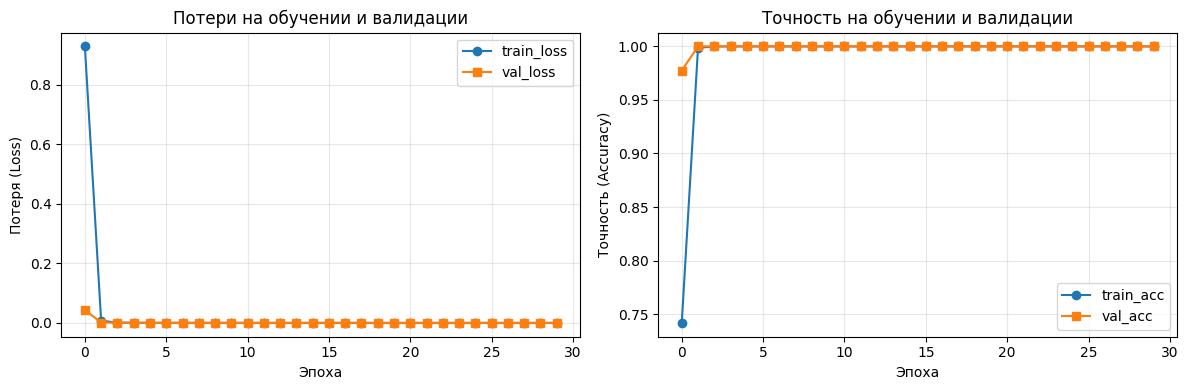


Лучшая val_loss: 0.0000
Лучшая val_accuracy: 1.0000


In [9]:
plt.figure(figsize=(12,4))

# График потерь
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss', marker='s')
plt.legend()
plt.xlabel('Эпоха')
plt.ylabel('Потеря (Loss)')
plt.title('Потери на обучении и валидации')
plt.grid(True, alpha=0.3)

# График точности
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc', marker='o')
plt.plot(history.history['val_accuracy'], label='val_acc', marker='s')
plt.legend()
plt.xlabel('Эпоха')
plt.ylabel('Точность (Accuracy)')
plt.title('Точность на обучении и валидации')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nЛучшая val_loss: {min(history.history['val_loss']):.4f}")
print(f"Лучшая val_accuracy: {max(history.history['val_accuracy']):.4f}")

## 10. Построение инференсных моделей

In [10]:
# Инференс-энкодер
encoder_model = Model(encoder_inputs, encoder_states)

# Инференс-декодер
decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_state_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_state_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_single_input = Input(shape=(1,), name='decoder_single_input')
dec_single_emb = dec_emb_layer(decoder_single_input)

dec_outputs, state_h, state_c = decoder_lstm(dec_single_emb, initial_state=decoder_states_inputs)
dec_outputs = decoder_dense(dec_outputs)

decoder_model = Model(
    [decoder_single_input] + decoder_states_inputs,
    [dec_outputs, state_h, state_c]
)

# Словари для обратного преобразования
reverse_target_word_index = {i: w for w, i in target_tokenizer.word_index.items()}
reverse_source_word_index = {i: w for w, i in input_tokenizer.word_index.items()}

print("Инференс модели созданы успешно")

Инференс модели созданы успешно


## 11. Функция перевода

In [11]:
def translate_sentence(input_text, max_len=50):
    """
    Функция для перевода предложения с русского на английский.
    """
    # Токенизация входного текста
    input_seq = input_tokenizer.texts_to_sequences([input_text.lower()])
    
    if not input_seq or not input_seq[0]:
        return "Не удалось распознать текст."
    
    input_seq = pad_sequences(input_seq, maxlen=encoder_input_data.shape[1], padding='post')
    
    # Получение состояний энкодера
    states = encoder_model.predict(input_seq, verbose=0)
    
    # Первый токен декодера - 'start_'
    start_token = target_tokenizer.word_index.get('start_', None)
    
    if start_token is None:
        return "Токен начала не найден."
    
    target_seq = np.array([[start_token]])
    
    decoded_sentence = []
    
    for _ in range(max_len):
        output_tokens, h, c = decoder_model.predict([target_seq] + states, verbose=0)
        
        # output_tokens имеет форму (1, 1, vocab_size)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        
        # Если встретили токен конца, останавливаемся
        end_token = target_tokenizer.word_index.get('end_', -1)
        
        if sampled_token_index == end_token:
            break
        
        sampled_word = reverse_target_word_index.get(sampled_token_index, '')
        
        if sampled_word:
            decoded_sentence.append(sampled_word)
        
        # Обновляем target_seq (следующий вход) и состояния
        target_seq = np.array([[sampled_token_index]])
        states = [h, c]
    
    return ' '.join(decoded_sentence).capitalize()

print("Функция перевода готова")

Функция перевода готова


## 12. Тестирование перевода

In [12]:
# Тестовые предложения
test_sentences = [
    "кот видит собаку",
    "большой дом",
    "мышь бежит",
    "маленький кот ловит мышь",
    "собака бежит в дом",
    "кот видит мышь",
    "красный дом",
    "синий дом",
    "маленькая собака",
    "зеленый дом"
]

print("=== Результаты перевода ===\n")

for sent in test_sentences:
    translation = translate_sentence(sent)
    print(f"Исходный: {sent}")
    print(f"Перевод:   {translation}")
    print("-" * 40)

=== Результаты перевода ===

Исходный: кот видит собаку
Перевод:   Cat sees собаку
----------------------------------------
Исходный: большой дом
Перевод:   Big house
----------------------------------------
Исходный: мышь бежит
Перевод:   Mouse runs
----------------------------------------
Исходный: маленький кот ловит мышь
Перевод:   Small cat catches mouse
----------------------------------------
Исходный: собака бежит в дом
Перевод:   Dog runs в house
----------------------------------------
Исходный: кот видит мышь
Перевод:   Cat sees mouse
----------------------------------------
Исходный: красный дом
Перевод:   Red house
----------------------------------------
Исходный: синий дом
Перевод:   Blue house
----------------------------------------
Исходный: маленькая собака
Перевод:   Маленькая dog
----------------------------------------
Исходный: зеленый дом
Перевод:   Green house
----------------------------------------


## 13. Сохранение модели и токенизаторов

In [13]:
# Создаем директорию для сохранения
save_dir = 'deep-learning/lab2'
os.makedirs(save_dir, exist_ok=True)

# Сохраняем модель в формате .h5
model.save(f'{save_dir}/seq2seq_model.h5')
print(f"Модель сохранена в {save_dir}/seq2seq_model.h5")

# Сохраняем токенизаторы с помощью pickle
with open(f'{save_dir}/input_tokenizer.pickle', 'wb') as f:
    pickle.dump(input_tokenizer, f)

with open(f'{save_dir}/target_tokenizer.pickle', 'wb') as f:
    pickle.dump(target_tokenizer, f)

print(f"Токенизаторы сохранены в {save_dir}/")

# Сохраняем историю обучения
with open(f'{save_dir}/history.pickle', 'wb') as f:
    pickle.dump(history.history, f)

print(f"История обучения сохранена")

Модель сохранена в deep-learning/lab2/seq2seq_model.h5
Токенизаторы сохранены в deep-learning/lab2/
История обучения сохранена


## 14. Загрузка сохранённой модели и использование

In [14]:
# Загружаем модель
loaded_model = load_model(f'{save_dir}/seq2seq_model.h5')
print("Модель загружена")

# Загружаем токенизаторы
with open(f'{save_dir}/input_tokenizer.pickle', 'rb') as f:
    loaded_input_tokenizer = pickle.load(f)

with open(f'{save_dir}/target_tokenizer.pickle', 'rb') as f:
    loaded_target_tokenizer = pickle.load(f)

print("Токенизаторы загружены")

# Восстанавливаем архитектуру для инференса
# Извлекаем слои из загруженной модели
enc_emb_layer = loaded_model.get_layer('encoder_embedding')
enc_lstm_layer = loaded_model.get_layer('encoder_lstm')
dec_emb_layer = loaded_model.get_layer('decoder_embedding')
dec_lstm_layer = loaded_model.get_layer('decoder_lstm')
dec_dense_layer = loaded_model.get_layer('decoder_dense')

# Строим инференс-энкодер
encoder_inputs_inf = Input(shape=(None,))
enc_emb_inf = enc_emb_layer(encoder_inputs_inf)
_, state_h_inf, state_c_inf = enc_lstm_layer(enc_emb_inf)
encoder_model_inf = Model(encoder_inputs_inf, [state_h_inf, state_c_inf])

# Строим инференс-декодер
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_single_input = Input(shape=(1,))
dec_single_emb = dec_emb_layer(decoder_single_input)

dec_outputs, state_h, state_c = dec_lstm_layer(dec_single_emb, initial_state=decoder_states_inputs)
dec_outputs = dec_dense_layer(dec_outputs)

decoder_model_inf = Model(
    [decoder_single_input] + decoder_states_inputs,
    [dec_outputs, state_h, state_c]
)

# Словарь для обратного преобразования
rev_target = {i: w for w, i in loaded_target_tokenizer.word_index.items()}

print("Инференс модели восстановлены")

Модель загружена
Токенизаторы загружены
Инференс модели восстановлены


## 15. Функция перевода с использованием загруженной модели

In [15]:
def translate_with_loaded(text, max_len=50):
    """Функция перевода с использованием загруженной модели."""
    seq = loaded_input_tokenizer.texts_to_sequences([text.lower()])
    
    if not seq or not seq[0]:
        return "Не распознано"
    
    seq = pad_sequences(seq, maxlen=encoder_input_data.shape[1], padding='post')
    
    states = encoder_model_inf.predict(seq, verbose=0)
    
    target_seq = np.array([[loaded_target_tokenizer.word_index['start_']]])
    
    decoded = []
    
    for _ in range(max_len):
        out, h, c = decoder_model_inf.predict([target_seq] + states, verbose=0)
        
        idx = np.argmax(out[0, -1, :])
        
        if idx == loaded_target_tokenizer.word_index.get('end_', -1):
            break
        
        word = rev_target.get(idx, '')
        
        if word:
            decoded.append(word)
        
        target_seq = np.array([[idx]])
        states = [h, c]
    
    return ' '.join(decoded).capitalize()


# Тестируем загруженную модель
print("=== Тестирование загруженной модели ===\n")

for sent in test_sentences:
    print(f"Исходный: {sent}")
    print(f"Перевод:  {translate_with_loaded(sent)}")
    print("-" * 40)

=== Тестирование загруженной модели ===

Исходный: кот видит собаку
Перевод:  Cat sees собаку
----------------------------------------
Исходный: большой дом
Перевод:  Big house
----------------------------------------
Исходный: мышь бежит
Перевод:  Mouse runs
----------------------------------------
Исходный: маленький кот ловит мышь
Перевод:  Small cat catches mouse
----------------------------------------
Исходный: собака бежит в дом
Перевод:  Dog runs в house
----------------------------------------
Исходный: кот видит мышь
Перевод:  Cat sees mouse
----------------------------------------
Исходный: красный дом
Перевод:  Red house
----------------------------------------
Исходный: синий дом
Перевод:  Blue house
----------------------------------------
Исходный: маленькая собака
Перевод:  Маленькая dog
----------------------------------------
Исходный: зеленый дом
Перевод:  Green house
----------------------------------------


## 16. Оценка качества перевода (BLEU)

In [16]:
try:
    import nltk
    from nltk.translate.bleu_score import corpus_bleu
    
    # Вычисляем BLEU на тестовой выборке
    test_size = min(100, len(val_idx))
    test_indices = val_idx[:test_size]
    
    references = []
    hypotheses = []
    
    for idx in test_indices:
        # Эталонный перевод
        ref = raw_english[idx].lower().split()
        references.append([ref])
        
        # Предсказанный перевод
        hyp = translate_sentence(raw_russian[idx]).lower().split()
        hypotheses.append(hyp)
    
    bleu_score = corpus_bleu(references, hypotheses)
    
    print(f"=== Оценка качества ===")
    print(f"BLEU Score на {test_size} примерах: {bleu_score:.4f}")
    
except ImportError:
    print("NLTK не установлен. Для установки выполните: pip install nltk")
except Exception as e:
    print(f"Ошибка при вычислении BLEU: {e}")

=== Оценка качества ===
BLEU Score на 100 примерах: 0.5590


## 17. Выводы

### Результаты работы:

1. **Подготовка данных**: Загружен/сгенерирован параллельный корпус, выполнена токенизация и подготовка последовательностей.

2. **Модель**: Построена архитектура Seq2Seq с LSTM (latent_dim=256), включающая энкодер и декодер.

3. **Обучение**: Модель обучена с использованием EarlyStopping для предотвращения переобучения.

4. **Инференс**: Реализована функция перевода для новых предложений.

5. **Сохранение/Загрузка**: Модель и токенизаторы сохранены и успешно загружены.

### Возможные улучшения:
- Увеличение размера скрытого состояния (latent_dim)
- Использование Bidirectional LSTM
- Добавление механизма внимания (Attention)
- Использование предобученных эмбеддингов (FastText, Word2Vec)
- Увеличение количества обучающих данных